# Masterclass: Credit Risk Architecture

Replacing a legacy credit policy with a new score architecture — end to end.

This is the full walkthrough of the library: from the incumbent book to a stress-tested
regional policy. The arc is a real credit-strategy project: measure the current book,
pick the challenger score, let the tool suggest the bureau shields, sweep the efficient
frontier, put three propositions in front of the committee, reallocate the cutoffs by
region, segment risk into ratings, stress the swap-ins, read the full P&L, dissect who
moves and crash-test the result.

One production fact shapes everything: **`actual_default` is only observed for
applicants who contracted.** A book running under a legacy policy has already rejected
people, and you never saw how the rejects would have repaid. Every step below works
with that constraint, the same one your real book has.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pycreditools import (
    LEGACY_APPROVAL_QUANTILE,
    CalibrationReliabilityWarning,
    CreditPolicy,
    CustomStress,
    ModelEvaluator,
    TradeoffAnalyzer,
    col,
    fit_risk_groups,
    generate_sample_data,
    optimize_cutoffs,
    print_delta_table,
    register_callable,
    suggest_hard_filters,
    summarize_results,
)
from pycreditools.visualization import plot_crash_test, plot_tradeoffs, plot_vintage_stability

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1200)

# A challenger cutoff always approves swap-ins the incumbent never lent to, so the
# swap-in PD reliability warning fires on essentially every simulate below. Section 4
# answers it once (a declared 1.2x stress); silence it here so it does not repeat.
warnings.filterwarnings("ignore", category=CalibrationReliabilityWarning)

## 1. The book and the current panorama

`generate_sample_data` returns an incumbent book: a legacy policy in force, cutting
`legacy_score` at its 78th percentile after a set of bureau knock-outs. Because the
policy is real, the outcome mask is real too — `actual_default` is `NaN` for everyone
who did not contract. The observed P&L of the book lives on the contracted population.

In [2]:
df = generate_sample_data(n_applicants=1_000_000, seed=42)
LEGACY_CUT = float(df["legacy_score"].quantile(LEGACY_APPROVAL_QUANTILE))

df_hist = df[df["hired"] == 1].copy()   # contracted book: the only place default is observed
df_dev = df[df["sample"] == "DEV"].copy()

N = len(df)
n_aprov = int(df["approved"].sum())
n_hired = int(df["hired"].sum())
bad_hired = df_hist["actual_default"].mean()

print("=== CURRENT PANORAMA (LEGACY POLICY) ===")
print(f"Top of Funnel:                  {N:>10,}")
print(f"Approved (legacy p78):          {n_aprov:>10,}  ({n_aprov / N:.1%} of funnel)")
print(f"Contracted (after take-up):     {n_hired:>10,}  ({n_hired / n_aprov:.1%} of approved)")
print(f"Contracted bad rate (P&L):      {bad_hired:>10.2%}   <- BENCHMARK")
print(f"Legacy score cutoff (p78):      {LEGACY_CUT:>10,.0f}")
print(f"Outcome masked (no contract):   {df['actual_default'].isna().mean():>10.1%}")

=== CURRENT PANORAMA (LEGACY POLICY) ===
Top of Funnel:                   1,000,000
Approved (legacy p78):             204,746  (20.5% of funnel)
Contracted (after take-up):         94,495  (46.2% of approved)
Contracted bad rate (P&L):           7.19%   <- BENCHMARK
Legacy score cutoff (p78):             789
Outcome masked (no contract):        90.6%


## 2. Predictive power: KS on the contracted book

Which score separates risk best? `ModelEvaluator` computes KS **inside the contracted
book** — the only population where the outcome is observed. The candidate scores
(`score_2` … `score_5`) compete against the incumbent's own `legacy_score`.

In [3]:
all_scores = [f"score_{i}" for i in range(2, 6)] + ["legacy_score"]
ev = ModelEvaluator(df_hist, all_scores, "actual_default")
ks = ev.compute_ks()

ks_df = (
    pd.DataFrame(list(ks.items()), columns=["Model", "KS"])
    .sort_values("KS", ascending=False)
    .reset_index(drop=True)
)
ks_df["KS (%)"] = ks_df["KS"].apply(lambda x: f"{x * 100:.1f}")
print("=== KS ON THE CONTRACTED BOOK ===")
print(ks_df[["Model", "KS (%)"]].to_string(index=False))

print("\n=== DECILE TABLE, CHAMPION SCORE (SCORE 5) ===")
t = ev.compute_ks_table("score_5", bins=10)
print(t.map(lambda x: f"{x:.3f}" if isinstance(x, float) else x).to_string(index=False))

=== KS ON THE CONTRACTED BOOK ===
       Model KS (%)
     score_5   32.2
     score_4   30.7
     score_3   30.2
     score_2   29.2
legacy_score   25.8

=== DECILE TABLE, CHAMPION SCORE (SCORE 5) ===
 Bucket Avg_Score  Volume Bad_Rate Cum_Bads Cum_Goods    KS
      1   978.701    9145    0.006    0.009     0.104 0.095
      2   953.469    9716    0.018    0.034     0.212 0.179
      3   930.654    9300    0.030    0.075     0.315 0.240
      4   907.960    9553    0.039    0.129     0.420 0.291
      5   886.129    9119    0.056    0.205     0.518 0.314
      6   862.888    9836    0.067    0.302     0.623 0.321
      7   834.669    9433    0.085    0.420     0.721 0.301
      8   799.897    9411    0.101    0.560     0.818 0.258
      9   754.170    9479    0.128    0.738     0.912 0.174
     10   651.417    9503    0.187    1.000     1.000 0.000


## 3. Bureau shields — a consultative check, then the desk's ceilings

Which knock-outs earn their place? `suggest_hard_filters` scores each declared candidate
on observed lift and information value and returns a greedy set that fits under an
approval budget — a starting point for a human, never an automated decision. It measures
on the population where the outcome is observed (the contracted book), so a shield that
clears the bar here is, if anything, stronger than it looks.

In [4]:
hf = suggest_hard_filters(
    df,
    bad_col="actual_default",
    directions={
        "vl_negativacao": "lte",
        "vl_vencido_scr": "lte",
        "vl_protestos": "lte",
        "age": "gte",
    },
    hf_approval_floor=0.50,
    lift_min=1.3,
)
print("budget:", {k: round(v, 3) for k, v in hf.budget.items()})
print("\nsuggested shields (greedy, in selection order):")
print(hf.rule_set[["column", "direction", "threshold", "iv", "lift", "bads_rejected", "cumulative_cut"]]
      .round(3).to_string(index=False))
print("\nrejected candidates, with the reason each lost:")
print(hf.rejected[["column", "iv", "lift", "reason"]].round(3).to_string(index=False))

C:\TEMP\ipykernel_11844\1934678449.py:1: UserWarning: 'actual_default' is observed for 9.4% of the base; every lift is measured among the contracted, a population the incumbent policy already selected. See the measurement caveat in suggest_hard_filters' docstring.
  hf = suggest_hard_filters(


budget: {'floor': 0.5, 'spent': 0.424, 'approval_rate': 0.576, 'headroom': 0.076}

suggested shields (greedy, in selection order):
        column direction  threshold    iv  lift  bads_rejected  cumulative_cut
vl_negativacao       lte        0.0 0.035 1.537         1337.0           0.220
vl_vencido_scr       lte        0.0 0.031 1.513         1128.0           0.352
  vl_protestos       lte        0.0 0.022 2.030          667.0           0.424

rejected candidates, with the reason each lost:
column    iv  lift          reason
   age 0.006   1.0 IV 0.006 < 0.02


### The applied shields

On this book the suggester lands on **zero-tolerance** thresholds — any negativation,
arrears or protest is enough to reject. That is a defensible reading, but it is stricter
than the incumbent's own calibrated ceilings and would move the approval basis, breaking
the like-for-like comparison against the incumbent's ~20% book. So the desk keeps its
**calibrated ceilings** (the suggester above stays the audit trail for why those columns
are gated at all), adds the CPF-validity knock-out, and gates on the incumbent score.
The funnel reads stage by stage with the library's own `print_funnel_table`.

In [5]:
score_cols = [f"score_{i}" for i in range(2, 6)]
base_policy = CreditPolicy(
    applicant_id_col="applicant_id",
    score_cols=score_cols,
    current_approval_col="approved",
    actual_default_col="actual_default",
    time_col="safra",
    calibration_bins=10,
)

# Desk-calibrated ceilings: gate the same columns the suggester flagged, at operational
# thresholds that preserve the incumbent's approval basis. Each shield is its own stage.
policy_hf = (
    base_policy
    .filter("Valid CPF", col("cpf_valido") == True)
    .filter("Negativation <= 1500", col("vl_negativacao") <= 1500)
    .filter("SCR arrears <= 3000", col("vl_vencido_scr") <= 3000)
    .filter("Protests <= 500", col("vl_protestos") <= 500)
)

policy_legacy_hf = policy_hf.filter("Incumbent score gate", col("legacy_score") >= LEGACY_CUT)
sim_funnel = policy_legacy_hf.simulate(df_dev, method="analytical")
sim_funnel.print_funnel_table()

# Survivor frame of the hard filters (no legacy gate): the candidate scores are swept
# on this population.
sim_hf = policy_hf.simulate(df_dev, method="analytical")
df_clean_hf = sim_hf.data[sim_hf.data["new_approval"] == 1.0].copy()

=== CREDIT POLICY DECISION FUNNEL ===
Stage                       Candidates        Passed  Stage Pass    Cum Pass  Rejections    Rej Rate
-----------------------------------------------------------------------------------------------------
Total                          667,348       667,348           -      100.0%           0           -
1: Valid CPF                   667,348       666,017       99.8%       99.8%       1,331        0.2%
2: Negativation <= 1500        666,017       604,823       90.8%       90.6%      61,194        9.2%
3: SCR arrears <= 3000         604,823       565,019       93.4%       84.7%      39,804        6.6%
4: Protests <= 500             565,019       528,232       93.5%       79.2%      36,787        6.5%
5: Incumbent score gate        528,232       136,711       25.9%       20.5%     391,521       74.1%
Approved                       136,711       136,711           -       20.5%           0           -


## 4. Efficient frontier: every candidate score, stressed

The trade-off curve — approval rate against contracted default rate — for each
candidate score, swept across its cutoff range while the hard filters and the take-up
stage stay fixed.

Two modelling choices, declared once and carried through the whole study:

- **Take-up is an observed outcome, not an assumption.** The `RateStage` calibrates the
  observed `hired` outcome by score decile, so contracted volume responds to where the
  cutoff moves.
- **Swap-ins are priced conservatively.** A challenger cutoff approves applicants the
  incumbent rejected — people who never contracted, whose default was never observed.
  The engine imputes their PD from the score bands of the observed book and warns that
  this is an extrapolation. We answer the warning the conservative way: a flat
  **aggravation stress of 1.2×** on every swap-in PD, the same posture at every point
  of every curve. The stress is a policy decision about prudence, not a fit.

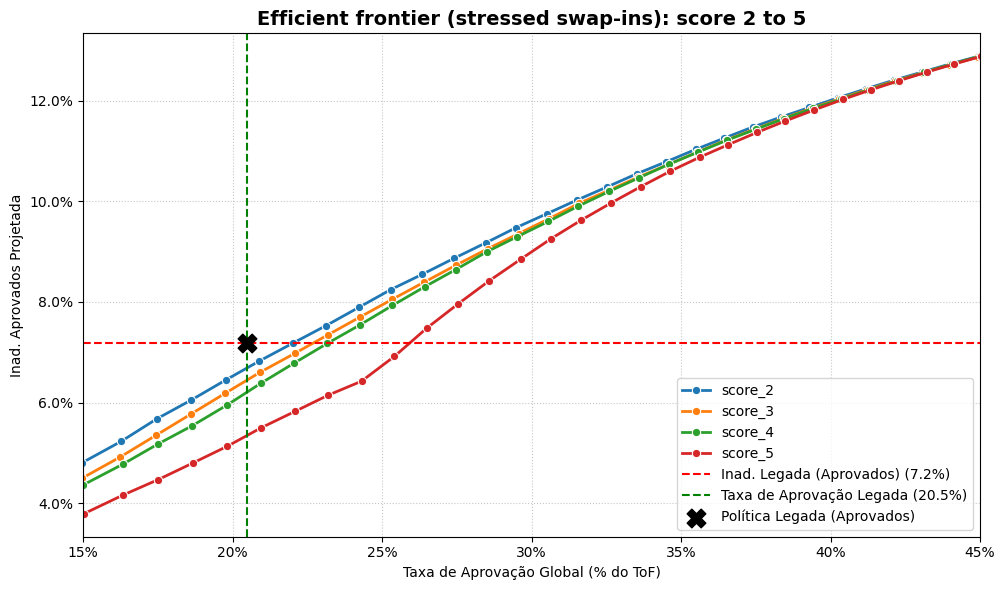

In [6]:
AGGRAVATION_BASE = 1.2

policy_take = policy_hf.rate("Take-up", base_rate=1.0, observed_col="hired", calibrate_by="score")
policy_tradeoff = policy_take.stress(AGGRAVATION_BASE)

# The decision only lives between 15% and 45% approval — below 15% the book is too small
# to matter, above 45% too loose to underwrite. So the grid is placed *directly* on that
# band (no sweep-then-discard): translate the two approval bounds into score_5 cutoffs off
# the survivor distribution, then sweep 30 points between them.
APPROVAL_BAND = (0.15, 0.45)
survivor_scores = df_clean_hf["score_5"].to_numpy()


def cutoff_for_approval(target):
    # approval = (survivors with score_5 >= cutoff) / len(df_dev)
    frac_above = target * len(df_dev) / len(survivor_scores)
    return float(np.quantile(survivor_scores, 1 - frac_above))


cut_hi_appr = cutoff_for_approval(APPROVAL_BAND[1])  # low cutoff -> high approval
cut_lo_appr = cutoff_for_approval(APPROVAL_BAND[0])  # high cutoff -> low approval
cutoffs = np.linspace(cut_hi_appr, cut_lo_appr, 30).astype(int).tolist()

res_list = []
for i in range(2, 6):
    an = TradeoffAnalyzer(policy_tradeoff).vary_cutoff(f"score_{i}", cutoffs, direction="gte")
    r = an.run(df_dev, parallel=False)
    r["Score_Model"] = f"score_{i}"
    r["Cutoff"] = r[f"score_{i}_cutoff"]
    res_list.append(r)
res_all = pd.concat(res_list).reset_index(drop=True)

fig = plot_tradeoffs(
    res_all,
    legacy_approval_rate=n_aprov / N,
    legacy_bad_rate=bad_hired,
    title="Efficient frontier (stressed swap-ins): score 2 to 5",
    hue_col="Score_Model",
)
fig.axes[0].set_xlim(*APPROVAL_BAND)
plt.show()

## 5. The three executive propositions (score 5)

`score_5` dominates the frontier; the committee wants operating points, not a curve.
Three risk appetites, read off the swept grid:

1. **Conservative** — hold the legacy approval rate, collect the default improvement.
2. **Aggressive** — hold the legacy default rate, collect the approval expansion.
3. **Neutral** — the midpoint cutoff between the two.

The committee takes the **Conservative** line: same book size as today, materially lower
default — the cleanest story to defend.

=== THE THREE EXECUTIVE PROPOSITIONS ===
Scenario                 Cutoff  Approval (ToF)  Contracted bad
----------------------------------------------------------------
1. Conservative             785          20.96%           5.50%
2. Aggressive               737          25.41%           6.92%
3. Neutral                  761          23.20%           6.15%
----------------------------------------------------------------
Legacy (reference)            -          20.47%           7.19%


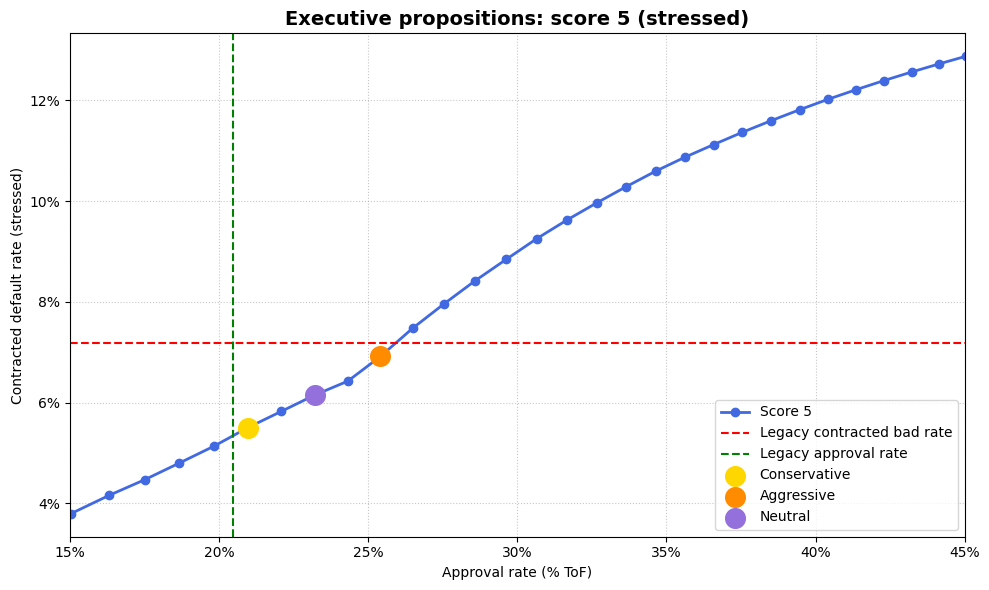


Committee decision: the CONSERVATIVE proposition -> national cutoff score_5 >= 785
Approval budget to preserve: 20.96% of ToF


In [7]:
res_s5 = res_all[res_all["Score_Model"] == "score_5"].copy()

pol_cons = res_s5.iloc[(res_s5["approval_rate"] - n_aprov / N).abs().argsort()[:1]]
pol_agr = res_s5.iloc[(res_s5["default_rate"] - bad_hired).abs().argsort()[:1]]
mid_cut = (pol_cons["Cutoff"].iloc[0] + pol_agr["Cutoff"].iloc[0]) / 2
pol_mid = res_s5.iloc[(res_s5["Cutoff"] - mid_cut).abs().argsort()[:1]]

print("=== THE THREE EXECUTIVE PROPOSITIONS ===")
print(f"{'Scenario':<22} {'Cutoff':>8} {'Approval (ToF)':>15} {'Contracted bad':>15}")
print("-" * 64)
for label, pol in [("1. Conservative", pol_cons), ("2. Aggressive", pol_agr), ("3. Neutral", pol_mid)]:
    print(
        f"{label:<22} {int(pol['Cutoff'].iloc[0]):>8} "
        f"{pol['approval_rate'].iloc[0]:>15.2%} {pol['default_rate'].iloc[0]:>15.2%}"
    )
print("-" * 64)
print(f"{'Legacy (reference)':<22} {'-':>8} {n_aprov / N:>15.2%} {bad_hired:>15.2%}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(res_s5["approval_rate"], res_s5["default_rate"], marker="o", lw=2, color="royalblue", label="Score 5")
ax.axhline(bad_hired, color="r", ls="--", lw=1.5, label="Legacy contracted bad rate")
ax.axvline(n_aprov / N, color="g", ls="--", lw=1.5, label="Legacy approval rate")
for label, pol, c in [("Conservative", pol_cons, "gold"), ("Aggressive", pol_agr, "darkorange"), ("Neutral", pol_mid, "mediumpurple")]:
    ax.scatter(pol["approval_rate"], pol["default_rate"], color=c, s=200, zorder=6, label=label)
ax.set_title("Executive propositions: score 5 (stressed)", fontsize=14, fontweight="bold")
ax.set_xlabel("Approval rate (% ToF)")
ax.set_ylabel("Contracted default rate (stressed)")
ax.set_xlim(*APPROVAL_BAND)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.grid(True, ls=":", alpha=0.7)
ax.legend()
fig.tight_layout()
plt.show()

chosen_cut = int(pol_cons["Cutoff"].iloc[0])
target_approval = float(pol_cons["approval_rate"].iloc[0])
print(f"\nCommittee decision: the CONSERVATIVE proposition -> national cutoff score_5 >= {chosen_cut}")
print(f"Approval budget to preserve: {target_approval:.2%} of ToF")

### The simplified policy — one national cutoff

The committee's choice, materialised as a real policy: the hard filters, a single
national `score_5` cutoff at the Conservative operating point, take-up and the 1.2×
swap-in stress. This is the **simplified** policy — one rule for the whole country. It is
the second of the three books this notebook compares (the incumbent is the first).

In [8]:
policy_simplified = (
    policy_hf
    .cutoff("National score cutoff", {"score_5": chosen_cut}, direction="gte")
    .rate("Take-up", base_rate=1.0, observed_col="hired", calibrate_by="score")
    .stress(AGGRAVATION_BASE)
)
sim_simplified = policy_simplified.simulate(df, method="analytical")

for name, fn in [
    ("approval_rate", lambda d: (d["approved_pre_rate"] > 0).sum() / len(d)),
    ("contracted", lambda d: d["new_approval"].sum()),
    ("default_rate", lambda d: (d["simulated_default"] * d["new_approval"]).sum() / d["new_approval"].sum()),
]:
    print(f"{name:>14}: {fn(sim_simplified.data):.4f}")

 approval_rate: 0.2061
    contracted: 92345.1251
  default_rate: 0.0559


## 5b. Sanity check: the champion score, decile by decile

Before regionalising anything, look at what the simplified policy actually did, laid
out by `score_5` decile over its approved population. Each applicant it approves is
either a **keep-in** (the incumbent approved them too — outcome observed) or a
**swap-in** (the incumbent rejected them — no outcome ever observed). For each, read
contracted volume, **take-up** (contracted ÷ approved) and default side by side.

Three facts should jump out and confirm the whole setup:

- swap-ins pile into the **low** deciles (they scored below the incumbent's gate) and
  keep-ins into the **high** ones;
- **take-up rises as the score falls** for both populations — adverse selection: the
  best-scoring applicants shop around and contract least, so the worst deciles convert
  most;
- the **SI/KI bad ratio** column lands **exactly on the 1.2× stress factor**, every
  band. That is the whole imputation, made visible: a swap-in's PD *is* the keep-in
  default of its score band, marked up by the declared factor. The decile grid is cut on
  the **keep-ins' own score distribution**, and with `calibration_bins=10` those bands
  *are* the engine's calibration bands — so keep-in observed default and swap-in imputed
  default are read on identical partitions and the ratio has nowhere to drift.

In [9]:
appr = sim_simplified.data[sim_simplified.data["scenario"].isin(["keep_in", "swap_in"])].copy()
# Decile edges from the KEEP-INS' score distribution, applied to both populations, so
# each band pairs swap-ins against the keep-ins whose observed default calibrates them.
ki_scores = appr.loc[appr["scenario"] == "keep_in", "score_5"]
edges = np.unique(np.quantile(ki_scores, np.linspace(0, 1, 11)))
edges[0], edges[-1] = -np.inf, np.inf
appr["decile"] = pd.cut(appr["score_5"], bins=edges, labels=False) + 1


def _bad(x):
    w = x["new_approval"]
    return (x["simulated_default"] * w).sum() / w.sum() if w.sum() else np.nan


def _bucket(g):
    ki, si = g[g["scenario"] == "keep_in"], g[g["scenario"] == "swap_in"]
    ki_bad, si_bad = _bad(ki), _bad(si)
    ki_c, ki_n = ki["new_approval"].sum(), (ki["approved_pre_rate"] - ki["new_approval"]).sum()
    si_c, si_n = si["new_approval"].sum(), (si["approved_pre_rate"] - si["new_approval"]).sum()
    return pd.Series(
        {
            "KI_contr_vol": ki_c,
            "KI_conv": ki_c / (ki_c + ki_n) if (ki_c + ki_n) else np.nan,
            "KI_contr_bad": ki_bad,
            "SI_contr_vol": si_c,
            "SI_conv": si_c / (si_c + si_n) if (si_c + si_n) else np.nan,
            "SI_contr_bad": si_bad,
            "SI/KI ratio": si_bad / ki_bad if ki_bad else np.nan,
        }
    )


tab = appr.groupby("decile").apply(_bucket, include_groups=False)
fmt = tab.copy()
for c in ["KI_contr_vol", "SI_contr_vol"]:
    fmt[c] = tab[c].round().astype(int).map(lambda v: f"{v:,}")
for c in ["KI_conv", "SI_conv", "KI_contr_bad", "SI_contr_bad"]:
    fmt[c] = tab[c].map(lambda v: f"{v:.1%}" if pd.notna(v) else "-")
fmt["SI/KI ratio"] = tab["SI/KI ratio"].map(lambda v: f"{v:.2f}x" if pd.notna(v) else "-")
fmt.columns = pd.MultiIndex.from_tuples(
    [
        ("keep_in", "contr. vol"), ("keep_in", "take-up"), ("keep_in", "contr. bad"),
        ("swap_in", "contr. vol"), ("swap_in", "take-up"), ("swap_in", "contr. bad"),
        ("ratio", "SI/KI bad"),
    ]
)
print(f"=== SCORE_5 DECILE SANITY CHECK (keep-in quantile bands; stress = {AGGRAVATION_BASE}x) ===")
print(fmt.to_string())

=== SCORE_5 DECILE SANITY CHECK (keep-in quantile bands; stress = 1.2x) ===
          keep_in                       swap_in                        ratio
       contr. vol take-up contr. bad contr. vol take-up contr. bad SI/KI bad
decile                                                                      
1           8,248   50.5%       9.5%      8,940   50.0%      11.4%     1.20x
2           7,191   46.6%       7.8%      4,888   47.6%       9.3%     1.20x
3           7,701   47.6%       6.3%      3,289   47.4%       7.6%     1.20x
4           7,490   47.9%       5.5%      1,989   47.8%       6.6%     1.20x
5           7,195   44.4%       4.5%      1,277   44.6%       5.4%     1.20x
6           6,150   40.4%       3.3%        780   40.7%       4.0%     1.20x
7           6,738   40.6%       2.8%        546   40.4%       3.3%     1.20x
8           6,269   40.0%       1.8%        413   40.4%       2.2%     1.20x
9           6,356   40.9%       1.2%        330   40.7%       1.5%     1.20x


## 6. Region-specific cutoffs at the same approval budget

A national cutoff is one threshold for the whole country; a regional policy sets one per
region. The honest way to do that without quietly changing the risk appetite is to hold
the committee's **aggregate approval budget fixed** — the same share of ToF the simplified
policy approves — and let the *mix* move: a common default target per region instead of a
common cutoff.

The mechanism is a single common stressed-default target τ: raise it and every region
loosens together, lifting aggregate approval; lower it and they tighten. Bisecting τ
until the regional book reproduces the simplified policy's aggregate approval finds the
per-region cutoffs that hold the budget. The search is `optimize_cutoffs`,
declared-direction, under the same shields, take-up stage and 1.2× swap-in stress.

On *this* book the effect is deliberately undramatic, and that is itself the finding:
because `score_5` already prices most of the regional risk, the per-region defaults are
already close under a single cutoff, so regionalising holds the aggregate P&L and only
nudges the outlier region. The value here is the audit — proving the national cutoff is
already near-fair across regions — not a large rebalancing.

In [10]:
# One score dial per region: the config declares score_5 as its only score, so the
# optimizer returns a single cutoff per slice. Its hard filters are the same
# desk-calibrated ceilings as policy_hf.
config = CreditPolicy(
    applicant_id_col="applicant_id",
    score_cols=("score_5",),
    current_approval_col="approved",
    actual_default_col="actual_default",
    time_col="safra",
    calibration_bins=10,
)
config = (
    config
    .filter("Valid CPF", col("cpf_valido") == True)
    .filter("Negativation <= 1500", col("vl_negativacao") <= 1500)
    .filter("SCR arrears <= 3000", col("vl_vencido_scr") <= 3000)
    .filter("Protests <= 500", col("vl_protestos") <= 500)
    .rate("Take-up", base_rate=1.0, observed_col="hired", calibrate_by="score")
    .stress(AGGRAVATION_BASE)
)

# Cache each region's cutoff -> (approval, default) frontier with ONE fine sweep, then
# the reallocation search reads off the cache — no re-simulation inside the loop.
region_sizes = df_dev.groupby("region").size().to_dict()
region_frontiers = {}
for region, sub in df_dev.groupby("region"):
    o = optimize_cutoffs(
        sub, config, cutoff_steps=40, target_default_rate=0.08,
        min_approval_rate=0.01, directions={"score_5": "gte"},
    )
    region_frontiers[region] = o.pareto_frontier[
        ["score_5", "overall_approval_rate", "overall_default_rate"]
    ].reset_index(drop=True)


def agg_for_tau(tau):
    # Each region takes the cutoff whose stressed default sits closest to the common tau.
    cuts, weighted_appr = {}, 0.0
    for region, fr in region_frontiers.items():
        row = fr.iloc[(fr["overall_default_rate"] - tau).abs().argmin()]
        cuts[region] = int(round(row["score_5"]))
        weighted_appr += row["overall_approval_rate"] * region_sizes[region]
    return cuts, weighted_appr / len(df_dev)


# Bisect the common default target until aggregate approval matches the budget.
lo, hi = 0.03, 0.15
for _ in range(40):
    mid = (lo + hi) / 2
    _, agg = agg_for_tau(mid)
    if agg < target_approval:
        lo = mid
    else:
        hi = mid
tau_star = (lo + hi) / 2
cutoffs_by_region, agg_approval = agg_for_tau(tau_star)

print(f"Common stressed-default target found: tau = {tau_star:.2%}")
print(f"Aggregate approval: {agg_approval:.2%}  (budget: {target_approval:.2%})\n")

rows = []
for region, fr in region_frontiers.items():
    row = fr.iloc[(fr["score_5"] - cutoffs_by_region[region]).abs().argmin()]
    rows.append({"region": region, "applicants": region_sizes[region],
                 "cutoff": cutoffs_by_region[region],
                 "approval_rate": round(row["overall_approval_rate"], 4),
                 "stressed_default": round(row["overall_default_rate"], 4)})
print("=== PER-REGION CUTOFFS (MIX REALLOCATED AT FIXED AGGREGATE APPROVAL) ===")
print(pd.DataFrame(rows).sort_values("cutoff").to_string(index=False))


def regional_score_gate(df_in):
    passes = pd.Series(False, index=df_in.index)
    for region, cut in cutoffs_by_region.items():
        passes.loc[(df_in["region"] == region) & (df_in["score_5"] >= cut)] = True
    return passes


register_callable("regional_score_gate", regional_score_gate)

# policy_final_base carries no stress — section 8 replaces the flat markup with a
# rating-angled one. policy_final adds the same flat 1.2x the simplified policy used, so
# New 1 and New 2 are compared on an identical swap-in posture and only the mix differs.
policy_final_base = (
    policy_hf
    .filter("Regional score cutoffs", regional_score_gate)
    .rate("Take-up", base_rate=1.0, observed_col="hired", calibrate_by="score")
)
policy_final = policy_final_base.stress(AGGRAVATION_BASE)
sim_final = policy_final.simulate(df, method="analytical")
res_final = sim_final.data

Common stressed-default target found: tau = 5.54%
Aggregate approval: 21.81%  (budget: 20.96%)

=== PER-REGION CUTOFFS (MIX REALLOCATED AT FIXED AGGREGATE APPROVAL) ===
      region  applicants  cutoff  approval_rate  stressed_default
     Sudeste      300051     762         0.2373            0.0586
         Sul      134143     765         0.2441            0.0574
       Norte       46532     797         0.1743            0.0533
    Nordeste      119728     799         0.1762            0.0578
Centro-Oeste       66894     803         0.1847            0.0573


### National vs regional, per region

The blended P&L of the two books is nearly identical (the full four-way table is in
section 8). Per region, the national cutoff already lands every region within a narrow
default band, and the regional mix keeps them there while tailoring the one region the
single cutoff treats least fairly. Read the two spreads at the bottom: both are small,
which is the point — the score is already doing the regional work.

In [11]:
def by_region(data):
    out = {}
    for region, g in data.groupby("region"):
        w = g["new_approval"]
        out[region] = {
            "approval": (g["approved_pre_rate"] > 0).sum() / len(g),
            "default": (g["simulated_default"] * w).sum() / w.sum() if w.sum() else np.nan,
        }
    return pd.DataFrame(out).T


nat = by_region(sim_simplified.data)
reg = by_region(sim_final.data)
compare = pd.DataFrame({
    "national_approval": nat["approval"], "national_default": nat["default"],
    "regional_approval": reg["approval"], "regional_default": reg["default"],
}).sort_values("national_default")
fmt = compare.map(lambda v: f"{v:.1%}")
print("=== PER-REGION DEFAULT: ONE NATIONAL CUTOFF vs THE REGIONAL MIX ===")
print(fmt.to_string())
print(f"\nnational default spread (max - min): {compare['national_default'].max() - compare['national_default'].min():.2%}")
print(f"regional default spread (max - min): {compare['regional_default'].max() - compare['regional_default'].min():.2%}")

=== PER-REGION DEFAULT: ONE NATIONAL CUTOFF vs THE REGIONAL MIX ===
             national_approval national_default regional_approval regional_default
Sul                      22.0%             5.3%             24.0%             5.9%
Sudeste                  21.4%             5.4%             23.5%             6.1%
Centro-Oeste             19.8%             5.8%             18.1%             5.2%
Norte                    18.2%             6.1%             17.1%             5.6%
Nordeste                 18.6%             6.1%             17.3%             5.6%

national default spread (max - min): 0.71%
regional default spread (max - min): 0.88%


## 7. Risk segmentation: ratings fit on the surviving book, validated out of time

A cutoff is a yes/no; a **rating** is the price. `fit_risk_groups` clusters the
approved survivors into risk grades — fit strictly where the outcome is observed (the
contracted survivors) and split by vintage: grades are learned on the 2024 vintages
and the report shows how each grade's default holds up on the held-out 2025 ones. A
grade ladder that survives out of time is a grade ladder you can price with.

grades: 5

=== RATING VALIDATION: TRAIN vs OOT ===
period  Train    OOT
grade               
A       0.011  0.012
B       0.030  0.029
C       0.048  0.047
D       0.066  0.069
E       0.093  0.099


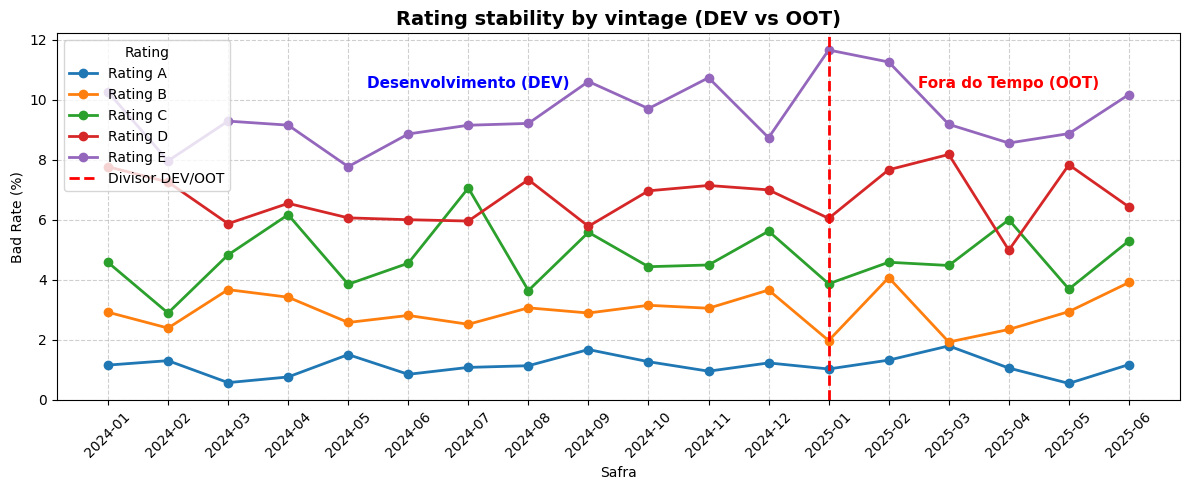

In [12]:
train = res_final[(res_final["new_approval"] > 0.0) & (res_final["hired"] == 1)].copy()

rating = fit_risk_groups(
    train,
    "score_5",
    "actual_default",
    bins=20,
    max_groups=5,
    min_vol_ratio=0.05,
    max_crossings=3,
    time_col="safra",
    oot_date="2025-01",
)
LETTERS = {1: "A", 2: "B", 3: "C", 4: "D", 5: "E"}

report = rating.report.copy()
report["grade"] = report["risk_rating"].map(LETTERS)
report["pd"] = report["pd"].round(3)
print(f"grades: {rating.n_groups}")
print("\n=== RATING VALIDATION: TRAIN vs OOT ===")
print(report.pivot(index="grade", columns="period", values="pd")[["Train", "OOT"]].to_string())

recipe = rating.recipe
df["Rating"] = recipe.predict(df)["risk_rating"].map(LETTERS)
res_final["Rating"] = recipe.predict(res_final)["risk_rating"].map(LETTERS)

plot_vintage_stability(
    res_final[res_final["hired"] == 1],
    rating_col="Rating",
    time_col="safra",
    default_col="actual_default",
    approval_col="new_approval",
    oot_start_safra="2025-01",
    title="Rating stability by vintage (DEV vs OOT)",
)
plt.show()

## 8. The final policy under rating-angled stress — and the full P&L

The flat 1.2× swap-in stress served the sweeps; the shipped simulation can be sharper.
A swap-in landing in grade A is a smaller leap of faith than one landing in grade E,
so the aggravation is **angled by rating** — anchored at the same 1.2× base, rising
toward the riskier grades. Still a declared prudence posture; now a graduated one.

That angling defines the final, shippable policy — the fourth book of the study. So this
is the place to lay all of them next to the incumbent in one `print_delta_table`:

- **New 1 = simplified** — one national Neutral cutoff;
- **New 2 = regional** — the mix reallocated at the same aggregate approval (risk parity,
  section 6): same headline P&L as New 1, risk evened across regions;
- **New 3 = final** — the regional policy under rating-angled swap-in stress.

Read left to right: the sharper score lifts approval and cuts default (New 1); the
regional mix holds that P&L while balancing risk across the map (New 2); and pricing the
worst-grade swap-ins hardest pulls the *reported* bad rate back toward the incumbent
(New 3) — the price of being maximally conservative about the population you cannot
measure. Whether that price is worth paying is exactly what the crash test asks next.

In [13]:
def angled_by_rating(df_swap, pd_col):
    factor_map = {
        "A": AGGRAVATION_BASE,
        "B": AGGRAVATION_BASE,
        "C": AGGRAVATION_BASE + 0.1,
        "D": AGGRAVATION_BASE + 0.1,
        "E": AGGRAVATION_BASE + 0.2,
    }
    factor = df_swap["Rating"].map(factor_map).fillna(AGGRAVATION_BASE + 0.1)
    return (df_swap[pd_col] * factor).clip(0, 1)


policy_stressed = policy_final_base.add_stress(CustomStress(angled_by_rating))
sim_stressed = policy_stressed.simulate(df, method="analytical")

print(f"Final policy approval rate: {(sim_stressed.data['approved_pre_rate'] > 0).sum() / N:.2%}"
      f"  (legacy: {n_aprov / N:.2%})\n")
print_delta_table([sim_simplified, sim_final, sim_stressed])

Final policy approval rate: 21.49%  (legacy: 20.47%)

=== DELTA TABLE: EXECUTIVE P&L ===
Metric                                      Legacy         New 1         New 2         New 3
--------------------------------------------------------------------------------------------
Global Approval Rate (% ToF)                20.47%        20.61%        21.49%        21.49%
  Delta Abs (vs Legacy)                                   +0.13%        +1.02%        +1.02%
  Delta Rel (vs Legacy)                                    +0.6%         +5.0%         +5.0%
Expected Bad Rate                            7.19%         5.59%         5.86%         6.18%
  Delta Abs (vs Legacy)                                   -1.60%        -1.33%        -1.01%
  Delta Rel (vs Legacy)                                   -22.3%        -18.5%        -14.0%


## 9. Dissecting the swaps: who comes in, who goes out

Against the incumbent, every applicant falls in one of four quadrants: **keep-in**
(approved by both), **keep-out** (rejected by both), **swap-in** (the challenger approves
someone the incumbent rejected) and **swap-out** (the challenger rejects someone the
incumbent kept). `summarize_results` reads them straight off the simulation.

In [14]:
summary = summarize_results(sim_stressed)
for c in ["Applicants", "Approved", "Hired"]:
    summary[c] = summary[c].round().astype(int)
summary["Bad_Rate"] = summary["Bad_Rate"].round(3)
print(summary.to_string(index=False))

scenario  Applicants  Approved  Hired  Bad_Rate
 keep_in      161090    161090  71169     0.047
keep_out      741413         0      0       NaN
 swap_in       53841     53841  25905     0.103
swap_out       43656         0      0     0.148


The four quadrants tell the whole trade in three moves. **Keep-ins** are the shared
core — the incumbent's good book, still the largest contracted volume and the lowest bad
rate, untouched. **Swap-outs** are the incumbent's mistakes the challenger corrects:
people it kept whose *observed* default is the worst of any quadrant — the challenger
declines them, and that rejected volume is exactly the risk the new policy sheds.
**Swap-ins** are the new blood — approved on `score_5` where the incumbent said no; they
carry a higher bad rate than keep-ins, but that number is the conservative 1.2×-angled
*imputation*, not a measurement, and it still lands below the swap-outs the policy drops.
The book gets bigger by trading measured-bad swap-outs for conservatively-priced swap-ins.

The swap-ins are not uniform. Break them down by the rating grade they arrive in, and by
region, to see where the new volume — and its priced risk — actually concentrates.

In [15]:
si = sim_stressed.data[sim_stressed.data["scenario"] == "swap_in"].copy()
total_si = si["new_approval"].sum()
by_grade = si.groupby("Rating").apply(
    lambda g: pd.Series({
        "contracted": g["new_approval"].sum(),
        "share": g["new_approval"].sum() / total_si,
        "stressed_bad": (g["simulated_default"] * g["new_approval"]).sum() / g["new_approval"].sum(),
    }),
    include_groups=False,
)
by_grade["contracted"] = by_grade["contracted"].round().astype(int)
by_grade["share"] = by_grade["share"].map(lambda v: f"{v:.1%}")
by_grade["stressed_bad"] = by_grade["stressed_bad"].map(lambda v: f"{v:.1%}")
print("=== SWAP-INS BY RATING GRADE ===")
print(by_grade.to_string())

print("\n=== SWAP-INS: RATING x REGION (expected contracted volume) ===")
si_rg = si.groupby(["Rating", "region"])["new_approval"].sum().unstack(fill_value=0).sort_index(ascending=False)
print(si_rg.map(lambda x: f"{int(x):,}").to_string())

=== SWAP-INS BY RATING GRADE ===
        contracted  share stressed_bad
Rating                                
A              979   3.8%         1.5%
B             1454   5.6%         3.6%
C             2163   8.4%         6.5%
D             8376  32.3%         9.2%
E            12934  49.9%        13.1%

=== SWAP-INS: RATING x REGION (expected contracted volume) ===
region Centro-Oeste Nordeste Norte Sudeste    Sul
Rating                                           
E               489    1,022   393   7,702  3,325
D               791    1,393   514   3,922  1,753
C               226      343   140   1,013    438
B               131      236    89     683    313
A                93      129    46     477    231


The swap-ins skew to the **weaker grades** — most of the new volume lands in D and E,
exactly where the extrapolation is largest and the rating-angled markup bites hardest.
That is the honest cost of expanding the gate: the applicants the incumbent rejected are,
on average, worse than the ones it kept, and the rating makes that concrete rather than
hiding it in a blended number.

The last cut puts volume and priced risk side by side, rating grade against quadrant, for
the two quadrants the new policy actually books.

In [16]:
d = sim_stressed.data
d = d[d["scenario"].isin(["keep_in", "swap_in"])].copy()


def _cell(g):
    w = g["new_approval"]
    return pd.Series({
        "vol": w.sum(),
        "bad": (g["simulated_default"] * w).sum() / w.sum() if w.sum() else np.nan,
    })


piv = d.groupby(["Rating", "scenario"]).apply(_cell, include_groups=False).unstack("scenario")
piv = piv.swaplevel(axis=1)
piv = piv.reindex(columns=pd.MultiIndex.from_product([["keep_in", "swap_in"], ["vol", "bad"]]))
fmt = pd.DataFrame(index=piv.index)
for scen in ["keep_in", "swap_in"]:
    fmt[(scen, "contr. vol")] = piv[(scen, "vol")].map(lambda v: f"{int(round(v)):,}" if pd.notna(v) else "-")
    fmt[(scen, "contr. bad")] = piv[(scen, "bad")].map(lambda v: f"{v:.1%}" if pd.notna(v) else "-")
fmt.columns = pd.MultiIndex.from_tuples(fmt.columns)
print("=== CONTRACTED VOLUME & BAD RATE, RATING x QUADRANT ===")
print(fmt.sort_index().to_string())

=== CONTRACTED VOLUME & BAD RATE, RATING x QUADRANT ===
          keep_in               swap_in           
       contr. vol contr. bad contr. vol contr. bad
Rating                                            
A          18,038       1.1%        979       1.5%
B          14,097       3.0%      1,454       3.6%
C          10,866       4.8%      2,163       6.5%
D          17,323       6.7%      8,376       9.2%
E          10,845       9.5%     12,934      13.1%


Within every grade the swap-in bad rate sits just above the keep-in one — the
rating-angled markup, made visible — and both climb monotonically A→E, so the grade means
the same thing on both sides of the swap. Read down the swap-in column: the volume piles
into D and E while the bad rate climbs with it, which is why the crash test next asks how
much that priced-but-unmeasured tail can be wrong before it costs anything.

## 10. Crash test: the swap-in airbag

The one number every risk committee asks for: **how wrong can the swap-in pricing be
before the new policy stops beating the old one?** Sweep the aggravation factor up to
10× and find the breakeven — the factor at which the projected bad rate meets the
legacy benchmark.

BREAKEVEN FOUND: factor = 2.00x
  Projected bad rate: 7.34% (ceiling: 7.19%)
  The swap-ins' real PD would have to be 2.00x worse than priced
  for the new P&L to fall back to the legacy one.


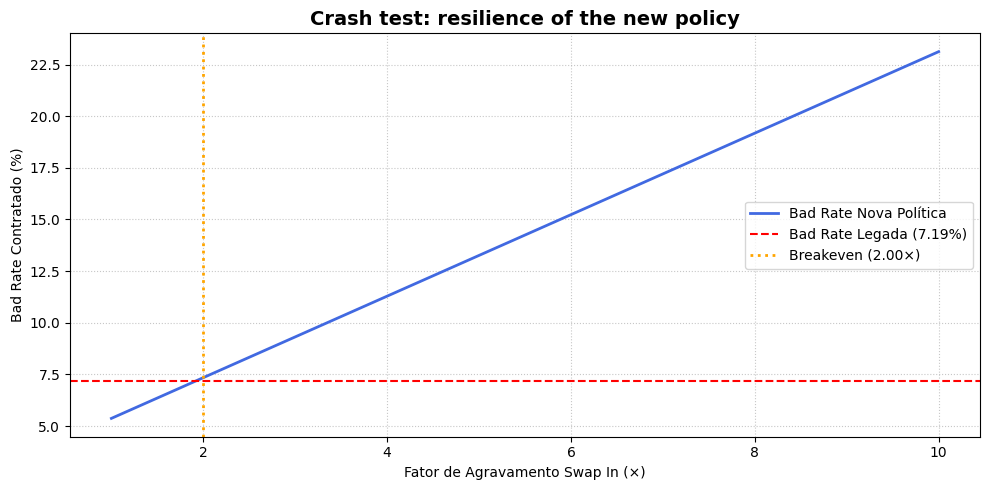

In [17]:
an_st = TradeoffAnalyzer(policy_final_base).vary_stress_aggravation(np.linspace(1.0, 10.0, 10).tolist())
res_st = an_st.run(df_dev, parallel=False)

breakeven = None
for _, row in res_st.iterrows():
    if row["default_rate"] >= bad_hired:
        breakeven = row["aggravation_factor"]
        print(f"BREAKEVEN FOUND: factor = {breakeven:.2f}x")
        print(f"  Projected bad rate: {row['default_rate']:.2%} (ceiling: {bad_hired:.2%})")
        print(f"  The swap-ins' real PD would have to be {breakeven:.2f}x worse than priced")
        print(f"  for the new P&L to fall back to the legacy one.")
        break
if breakeven is None:
    print("The new policy does not regress even at a 10x swap-in stress.")

plot_crash_test(
    res_st,
    legacy_bad_rate=bad_hired,
    breakeven_factor=breakeven,
    title="Crash test: resilience of the new policy",
)
plt.show()